# **_The t-test, et alia_**

What I've learned about the t-test so far:

- Assumptions

- Parameters

- Practical Applications

- Constraints

<hr style="height: 0; box-shadow: 0 0 5px 4px crimson; width: 90%;">

This notebook expands on my solutions to coding challenges from the t-tests section of Mike X. Cohen's Udemy course [Master statistics & machine learning: intuition, math, code](https://www.udemy.com/course/statsml_x).

<hr style="height: 0; box-shadow: 0 0 5px 4px crimson; width: 90%;">

## **_About the t-test_**

We use the t-test to measure whether the means of two samples are statistically
different from one another.

Specifically, whether an observed difference in means is larger than we'd expect from random sampling variation alone.

We generally assume the underlying populations are normally distributed...

- ...or that sample sizes are large enough for the sampling distribution of the mean to be approximately normal.

The formula, in a nutshell _(simplified case: equal sample sizes, shared
standard deviation)_:

$
\begin{aligned}
    \Huge
    t &= \frac{(\bar{x} - \bar{y}) \cdot \sqrt{n}}{s} \\
    \text{where:} \\
    t &\Rightarrow \text{t-value (t-statistic)} \\
    \bar{x} &\Rightarrow \text{mean of first sample} \\
    \bar{y} &\Rightarrow \text{mean of second sample} \\
    s &\Rightarrow \text{shared (pooled) sample standard deviation} \\
    n &\Rightarrow \text{sample size (assumed equal across both groups)}
\end{aligned}
$

Variations exist...

Different formulas for one-sample:

- Unequal-Variance (Welch's)

- Paired t-tests

But this captures the foundational shape:

- **SIGNAL** (mean difference) over **NOISE** (variability), scaled by how much data you have.

<hr style="height: 0; box-shadow: 0 0 5px 4px crimson; width: 90%;">

## **_1. Standard Deviation and the t-test_**

<hr style="height: 0; box-shadow: 0 0 5px 4px dodgerblue; width: 80%;">

### **_1a. Visualizing Increasing Standard Deviation_**

Before applying the t-test, build intuition for what increasing standard deviation looks like.

Assuming:

- Same population mean

- Same sample size

...but progressively more spread-out data.

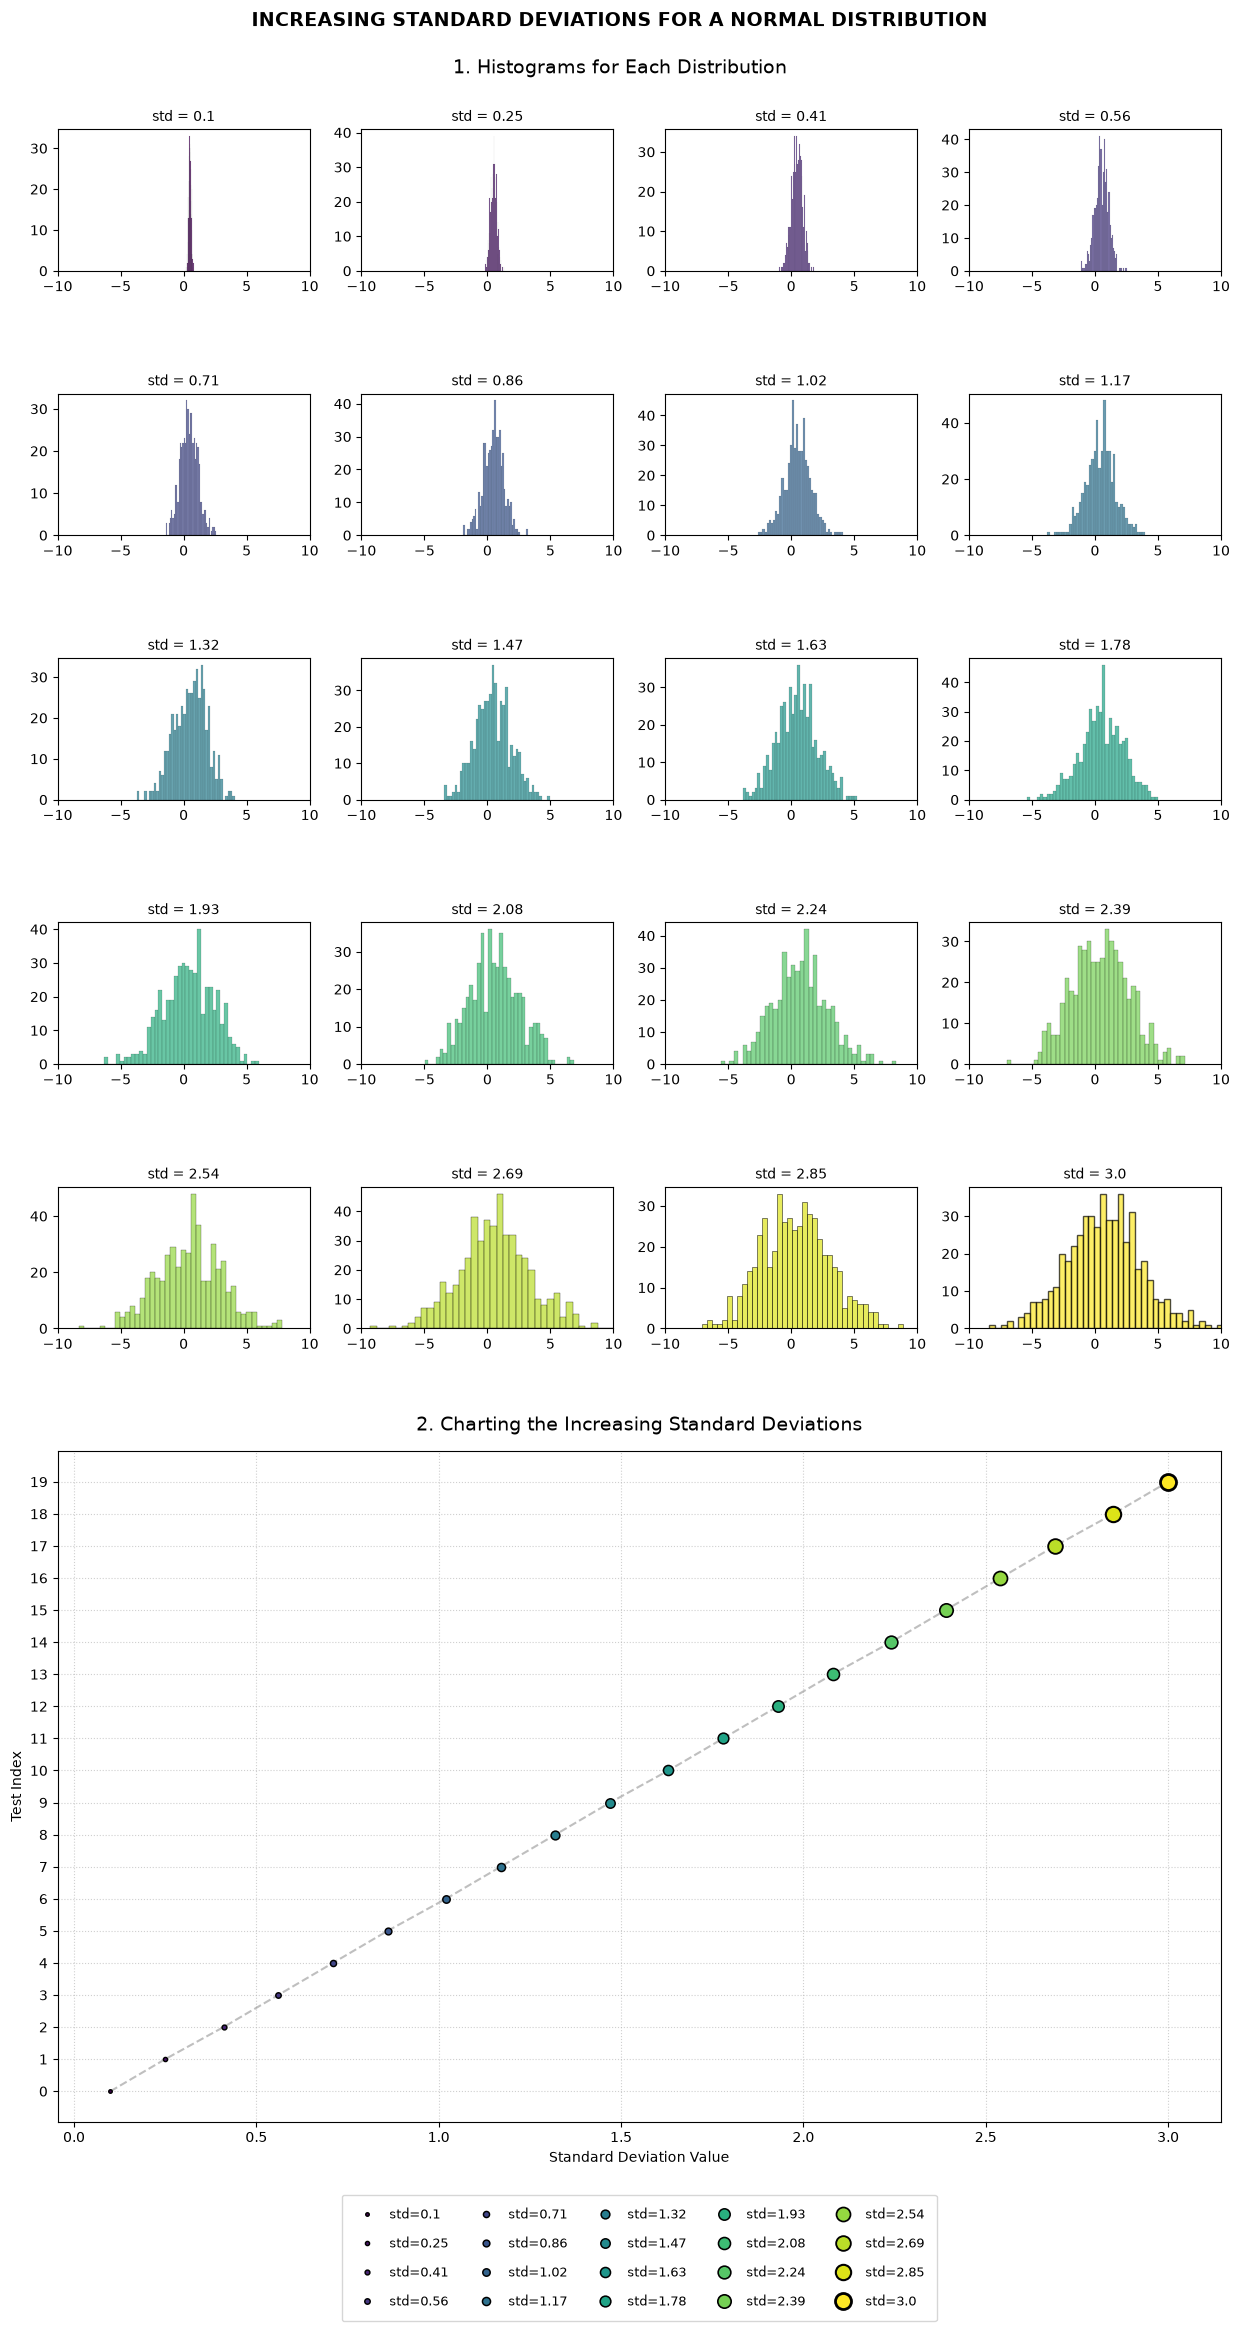

In [17]:
# Import required libraries:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

N_PTS = 500
nTests = 20
popMu = 0.5  # True population mean
forcedStd = np.round(np.linspace(0.1, 3, nTests), 2)

fig = plt.figure(figsize=(12.5, nTests + 4.5))
# NOTE: Assumes nTests is a multiple of 4. The GridSpec row's
#       math (nTests // 4 hist rows + 3 summary rows) breaks
#       silently for e.g. nTests = 21 (hist rows overflowing
#       into summary rows).
gs = GridSpec(nTests // 4 + 3, 4, figure=fig)
axes = [fig.add_subplot(gs[i // 4, i % 4]) for i in range(nTests)]

# Scale indicies to a 0.0 -> 1.0 float to sample the colormap.
# Yields smoothly transitioning RGBA color for each iteration
#  in loops below:
color_fracs = [i / (nTests - 1) for i in range(len(forcedStd))]
color_vals = [plt.cm.viridis(i) for i in color_fracs]

# Edge linewidth grows as std increases so later (noisier) histograms
#  have bolder outline. Purely for visual emphasis and not statistical:
line_widths = [(1 / (nTests - i)) for i in range(nTests)]

## === 1 === ##
# Plot histograms of the distributions with increasing standard deviations:
for i in range(nTests):
    data = np.random.normal(popMu, forcedStd[i], N_PTS)
    axes[i].hist(
        data,
        bins=40,
        color=color_vals[i],
        lw=line_widths[i],
        edgecolor="black",
        alpha=0.7,
    )
    axes[i].set_title(f"std = {forcedStd[i]}", fontsize=10)
    axes[i].set_xlim(-10, 10)

## === 2 === ##
# Plot the increasing standard deviations line chart.
# Spans rows 5 through 7, across all 4 columns:
stdDev_ax = fig.add_subplot(gs[nTests // 4 : (nTests // 4) + 3, :4])
axes.append(stdDev_ax)

# Draw continuous line making trend visually scannable:
stdDev_ax.plot(forcedStd, range(nTests), color="gray", linestyle="--", alpha=0.5)

# Marker size also grows with test index, reinforcing the same
#  "later = more spread out" cue on the summary plot:
for i, std_val in enumerate(forcedStd):
    stdDev_ax.plot(
        std_val,
        i,
        ".",
        color=color_vals[i],
        ms=(i * 0.95 + 5),
        mec="k",
        mew=line_widths[i] + 1,
        label=f"std={std_val}",
    )

stdDev_ax.set_ylabel("Test Index")
stdDev_ax.set_xlabel("Standard Deviation Value")
stdDev_ax.grid(True, linestyle=":", alpha=0.6)
stdDev_ax.set_yticks([i for i in range(nTests)])

# Configure the legend layout safely outside the plot area:
stdDev_ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=5,
    labelspacing=1.2,
    borderpad=1.0,
    fontsize=9,
)

# Titles/layout adjustments:
top_titles = r"$\mathbf{INCREASING\ STANDARD\ DEVIATIONS\ FOR\ A\ NORMAL\ DISTRIBUTION}$"
top_titles += "\n\n1. Histograms for Each Distribution"
plt.suptitle(top_titles, size=14, y=0.95)

bottom_titles = "\n\n2. Charting the Increasing Standard Deviations"
stdDev_ax.set_title(bottom_titles, size=14, pad=15)

# tight_layout + padding at the top for main suptitle:
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

<hr style="height: 0; box-shadow: 0 0 5px 4px dodgerblue; width: 80%;">

### **_1b. Increasing Standard Deviation, p-value and the t-test_**

With increasing standard deviation:

- Compute the **t-statistic** and **p-value** for each sample with one-sample t-test against fixed null:
    - $H0$: population mean = `0`

This isolates the effect of standard deviation on the test statistic without introducing a second varying sample.

Then:

1. Plot **t** against standard deviation

2. Plot **p** against standard deviation

3. Plot **t** against **p**

These hypothesis testing metrics indicate:

- **t-statistic**: The **SAMPLE STATISTIC** (test statistic):
    - Measures how far data deviates from the null hypothesis.

- **p-value**: The **PROBABILITY METRIC** (significance level):
    - Based on that test statistic, quantifies strength of evidence against the null hypothesis.

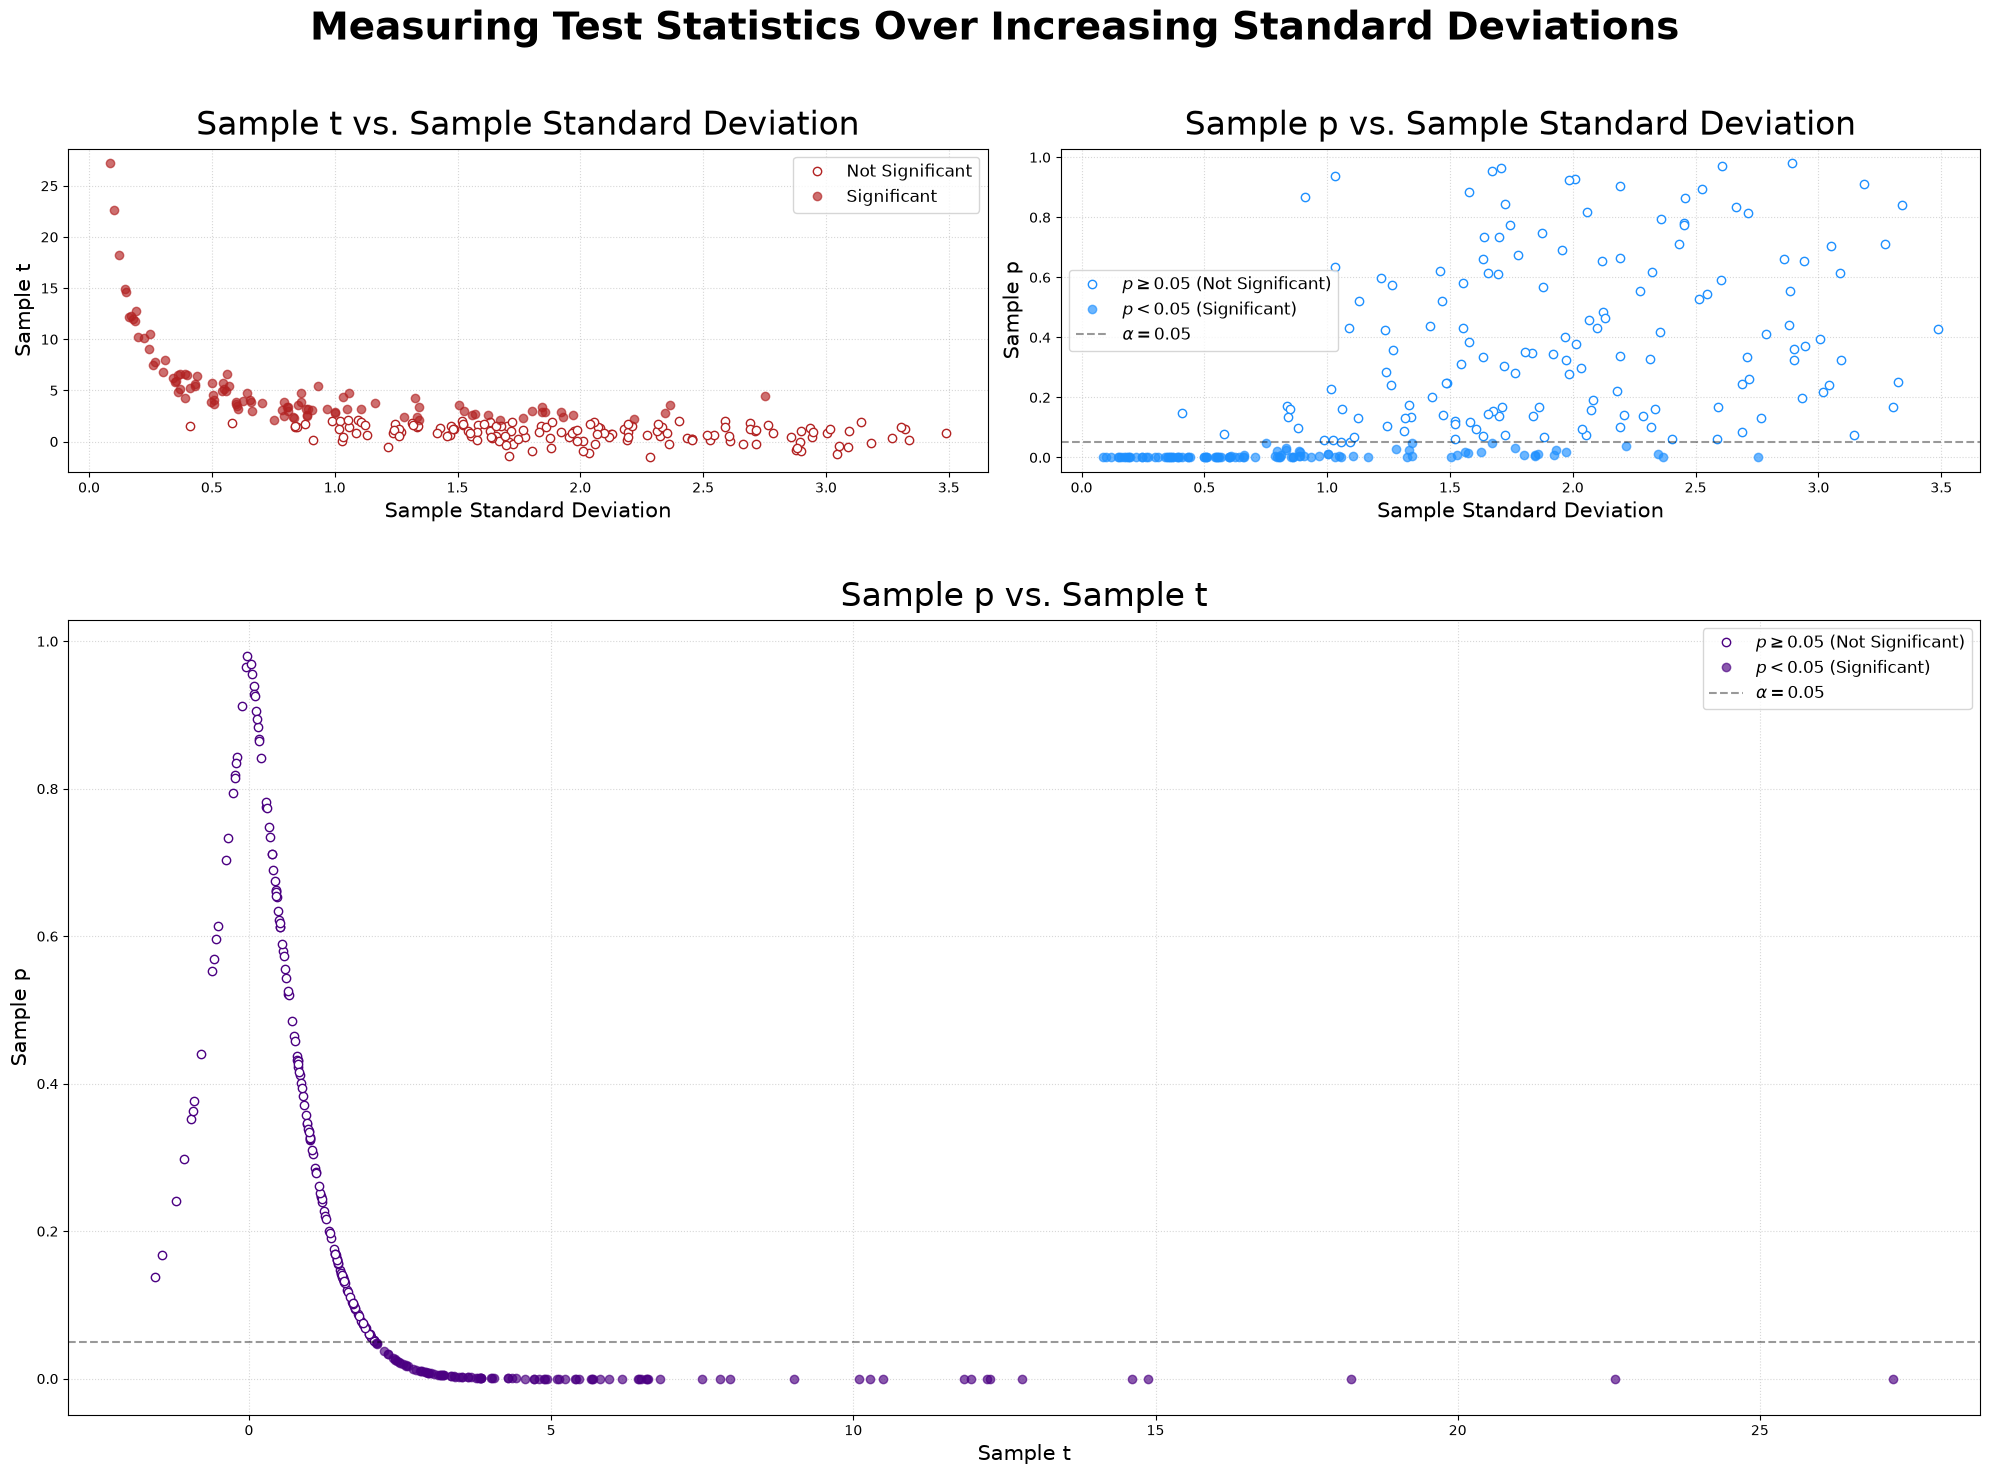

In [18]:
# Import required libraries:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
import scipy.stats as stats

N_PTS = 20
nTests = 250
popMu = 0.5  # True population mean
hNull = 0
forceStd = np.linspace(0.1, 3, nTests)

fig = plt.figure(figsize=(20, 15))
gs = GridSpec(3, 2, figure=fig)
axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1:, :]),
]

sampStd = np.zeros(nTests)
t = np.zeros(nTests)
p = np.zeros(nTests)
for i in range(nTests):
    data = np.random.normal(popMu, forceStd[i], N_PTS)
    sampStd[i] = np.std(data, ddof=1)
    tInd, pInd = stats.ttest_1samp(data, hNull)
    t[i] = tInd
    p[i] = pInd

# Boolean mask for statistical significance, alpha = 5%:
sig = p < 0.05
notSig = ~sig  # Bitwise NOT operator, i.e. ~x = -x - 1

# Color Palette:
mfAlt = "white" # Marker face color (alternate/insignificant data points)
mc1 = "firebrick"
mc2 = "dodgerblue"
mc3 = "indigo"

## === axes[0]: t VS. SAMPLE STANDARD DEVIATION === ##
axes[0].plot(
    sampStd[notSig],
    t[notSig],
    "o",
    mfc=mfAlt,
    mec=mc1,
    label="Not Significant",
)
axes[0].plot(
    sampStd[sig],
    t[sig],
    "o",
    color=mc1,
    alpha=0.65,
    label="Significant",
)
axes[0].set_title("Sample t vs. Sample Standard Deviation", size=24, pad=10)
axes[0].set_xlabel("Sample Standard Deviation", size=15)
axes[0].set_ylabel("Sample t", size=15)

## === axes[1]: p VS. SAMPLE STANDARD DEVIATION === ##
axes[1].plot(
    sampStd[notSig],
    p[notSig],
    "o",
    mfc=mfAlt,
    mec=mc2,
    label=r"$p \geq 0.05$ (Not Significant)",
)
axes[1].plot(
    sampStd[sig],
    p[sig],
    "o",
    color=mc2,
    alpha=0.65,
    label=r"$p < 0.05$ (Significant)",
)
axes[1].set_title("Sample p vs. Sample Standard Deviation", size=24, pad=10)
axes[1].set_xlabel("Sample Standard Deviation", size=15)
axes[1].set_ylabel("Sample p", size=15)
axes[1].axhline(y=0.05, color="k", ls="--", alpha=0.4, label=r"$\alpha = 0.05$")

## === axes[2]: P VS. T === ##
axes[2].plot(
    t[notSig],
    p[notSig],
    "o",
    mfc=mfAlt,
    mec=mc3,
    label=r"$p \geq 0.05$ (Not Significant)",
)
axes[2].plot(
    t[sig],
    p[sig],
    "o",
    color=mc3,
    alpha=0.65,
    label=r"$p < 0.05$ (Significant)",
)
axes[2].set_title("\nSample p vs. Sample t", size=24, pad=10)
axes[2].set_xlabel("Sample t", size=15)
axes[2].set_ylabel("Sample p", size=15)
axes[2].axhline(y=0.05, color="k", ls="--", alpha=0.4, label=r"$\alpha = 0.05$")

# Formatting loop:
for axis in axes:
    axis.grid(True, alpha=0.5, ls=":")
    axis.legend(fontsize=12, loc="best")

# Use raw string 'r' for complex LaTeX formatting strings:
supTitle = r"$\mathbf{Measuring\ Test\ Statistics\ Over\ Increasing\ Standard\ Deviations}$"
fig.suptitle(supTitle, size=28, y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

<hr style="height: 0; box-shadow: 0 0 5px 4px crimson; width: 90%;">

## **_2. Sample Size and the t-test_**

When sampling from a population, one single test isn't necessarily reliable.

Explore how **SAMPLE SIZE** affects the outcome of a two-samples unpaired **t-test**:

- Perform multiple t-tests on each sample size, then take the average.

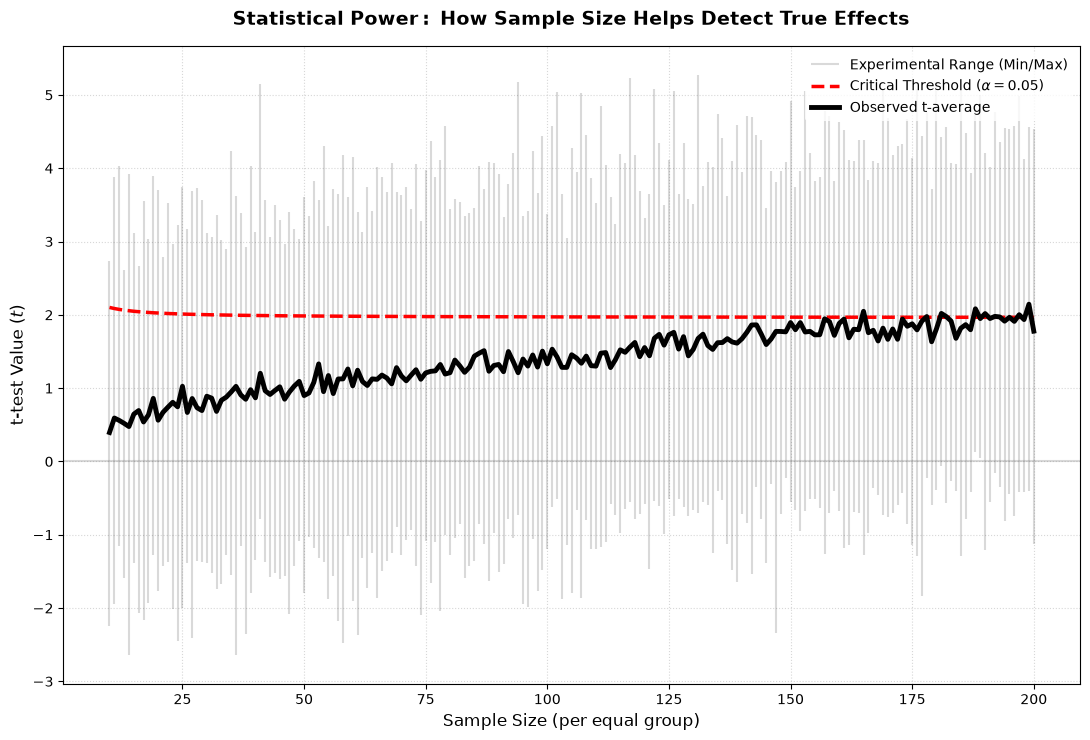

In [19]:
# Import required libraries:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

## === 1. INITIALIZE GENERATORS === ##
# Random seed within a specified range by default:
randNumGen1 = np.random.default_rng(seed=np.random.randint(0, 500))
randNumGen2 = np.random.default_rng(seed=np.random.randint(500, 1000))

# Swap in a fixed seed below for reproducible runs:
# randNumGen1 = np.random.default_rng(seed=42)  # Uncomment for reproducibility
# randNumGen2 = np.random.default_rng(seed=43)  # Uncomment for reproducibility

mu1 = 1
mu2 = 1.2  # True effect size = 0.2
minN = 10
maxN = 201
sampCounts = np.arange(minN, maxN)
n_samples = maxN - minN
n_experiments = 100
std_dev = 1.0
pValThresh = 0.05

tValMatrix = np.zeros((n_samples, n_experiments))
criticalTVals = np.zeros(n_samples)

# Track min and max for vectorized plotting later
min_t_vals = np.zeros(n_samples)
max_t_vals = np.zeros(n_samples)

## === 2. RUN MANY SIMULATIONS === ##
#  ...with increasing sample sizes. See how the test
#  statistic begins to align with the expected result:
for n in range(n_samples):
    samp_n = sampCounts[n]
    data1 = randNumGen1.normal(loc=mu1, scale=std_dev, size=(n_experiments, samp_n))
    data2 = randNumGen2.normal(loc=mu2, scale=std_dev, size=(n_experiments, samp_n))

    # "Student's" t-test (continuous data, roughly Gaussian, equal_var=True).
    #  Pooled variance, assumes both groups share the same population standard
    #  deviation (std_dev here):
    tValMatrixRow_n, _ = stats.ttest_ind(data2, data1, axis=1, equal_var=True)
    tValMatrix[n, :] = tValMatrixRow_n

    # Store boundaries for the vertical ranges:
    min_t_vals[n] = np.min(tValMatrixRow_n)
    max_t_vals[n] = np.max(tValMatrixRow_n)

    # Two-tailed critical t-value: threshold beyond which |t| is
    #  significant at alpha=0.05, given degree's of freedom (df)
    #  for this sample size:
    df = samp_n * 2 - 2
    criticalTVals[n] = stats.t.ppf(1 - pValThresh / 2, df)

## === 3 === ##
# PLOTTING AND FORMATTING
plt.figure(figsize=(11, 7.5))

# Represent sampling variability/noise of t-test result
plt.vlines(
    sampCounts,
    min_t_vals,
    max_t_vals,
    colors="black",
    alpha=0.15,
    linewidth=1.5,
    label="Experimental Range (Min/Max)",
)

# Plot theoretical/expected result:
plt.plot(sampCounts, criticalTVals, "r--", lw=2.5, label=r"Critical Threshold ($\alpha = 0.05$)")
# Plot empirical result of expirment:
plt.plot(sampCounts, np.mean(tValMatrix, axis=1), "k-", lw=3.5, label="Observed t-average")

# Visual labels/refinements:
plt.title(
    r"$\mathbf{Statistical\ Power:\ How\ Sample\ Size\ Helps\ Detect\ True\ Effects}$",
    size=14,
    pad=15,
)
plt.xlabel("Sample Size (per equal group)", size=12)
plt.ylabel("t-test Value ($t$)", size=12)
plt.grid(True, linestyle=":", alpha=0.5)
plt.axhline(0, color="gray", linestyle="-", alpha=0.3)
plt.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=10)

plt.tight_layout()
plt.show()

Run the code again, but try altering:

- **Standard Deviation** (`std_dev`)

- The difference between population **means** (`mu1`, `mu2`)

...to see how the results change.

<hr style="height: 0; box-shadow: 0 0 5px 4px crimson; width: 90%;">

## **_3. Permutation Testing_**

The **t-test** assumes the underlying data is normally distributed:

Permutation testing relaxes that assumption:

- Instead of relying on a formula, it builds the null distribution empirically

- It does this by repeatedly shuffling the combined data and recomputing the difference in means.

This directly reflects whatever is actually present in the data (skew, outliers, etc.) rather than smoothing it away with a parametric assumption.

This raises a new question:

- "Without a formula-based test statistic, how do we judge significance?"

So we compute a **Z-Score**:

- The observed difference...

- ...standardized against the **MEAN** and **STANDARD DEVIATION** of the permuted differences.

This is valid because of the **CENTRAL LIMIT THEOREM**:

- Though the underlying data (`dataA`, `dataB`) are deliberately right-skewed...

- The distribution of permuted mean differences tends toward normal as sample size grows.

**CLT** does the normalizing work that the t-test would otherwise assume up front.

The **LAW OF LARGE NUMBERS** explains a second effect visible in the plots below...

As we increase the number of permutations per experiment:

- Our estimate of the null distribution's mean and standard deviation becomes more accurate.

- So the resulting Z-score stabilizes, and its variance decreases.

That's what the top scatter plot shows: tighter spread in Z-value as permutation count grows.

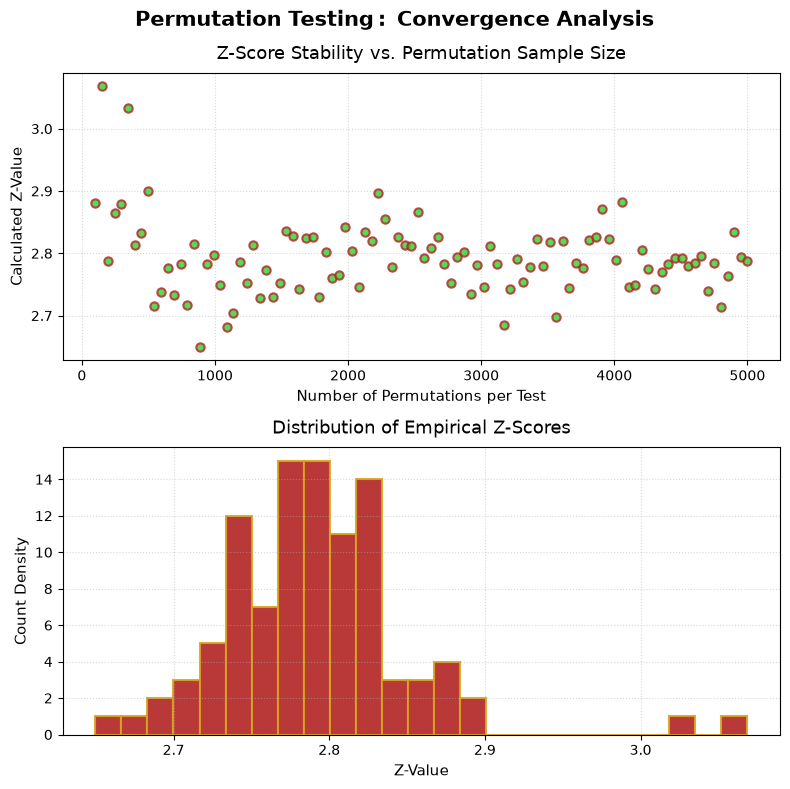

In [20]:
# Import required libraries:
import matplotlib.pyplot as plt
import numpy as np

## === 1. SIMULATE TWO DISTRIBUTIONS === ##
#  (Right-skewed distributions):
N = 100  # Number of samples per group:
rng = np.random.default_rng(seed=37)

randA = rng.standard_normal(N)
randA[randA > 0] = np.log(1 + randA[randA > 0])
dataA = 26 - randA * 10

randB = rng.standard_normal(N)
randB[randB > 0] = np.log(1 + randB[randB > 0])
dataB = 30 - randB * 10

# Combine data and calculate the true observed difference:
alldata = np.hstack((dataA, dataB))
obsval = np.mean(dataB) - np.mean(dataA)  # Observed effect: what we're testing against the null

## === 2. PERMUTATION TESTING SIMULATION === ##
nExper = 100
zScores = np.zeros(nExper)
nPerms = np.linspace(100, 5000, nExper, dtype=int)

# Create a local copy to shuffle in-place safely:
perm_data = alldata.copy()

for i in range(nExper):
    current_perms = nPerms[i]
    permDiffs = np.zeros(current_perms)

    for j in range(current_perms):
        # High-performance in-place shuffle:
        rng.shuffle(perm_data)
        # Reassign labels at random: split shuffled data down the middle,
        #  simulating "no true difference between groups" (the null hypothesis).
        permDiffs[j] = np.mean(perm_data[N:]) - np.mean(perm_data[:N])

    # Standardize obsval against the empirical null distribution.
    # Valid due to CLT: permDiffs trends normal as N grows, even though
    #  the raw data (dataA, dataB) are skewed.
    zScores[i] = (obsval - np.mean(permDiffs)) / np.std(permDiffs, ddof=1)

## === 3. PLOTTING AND VISUALIZATION === ##
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

# Top Plot: Z-score stability across increasing permutation counts:
axes[0].plot(
    nPerms,
    zScores,
    marker="o",
    mfc="limegreen",
    mec="firebrick",
    mew=1.5,
    ms=6,
    ls="none",
    alpha=0.8,
)
axes[0].set_xlabel("Number of Permutations per Test", size=11)
axes[0].set_ylabel("Calculated Z-Value", size=11)
axes[0].set_title("Z-Score Stability vs. Permutation Sample Size", size=13, pad=10)
axes[0].grid(True, linestyle=":", alpha=0.5)

# nPerms increases across experiments (100 -> 5000), so this
#  histogram mixes low- and high-precision Z-score estimates rather than
#  showing repeated trials at a fixed permutation count.
axes[1].hist(zScores, bins=25, color="firebrick", edgecolor="goldenrod", lw=1.5, alpha=0.9)
axes[1].set_xlabel("Z-Value", size=11)
axes[1].set_ylabel("Count Density", size=11)
axes[1].set_title("Distribution of Empirical Z-Scores", size=13, pad=10)
axes[1].grid(True, linestyle=":", alpha=0.5)

plt.suptitle(r"$\mathbf{Permutation\ Testing:\ Convergence\ Analysis}$", size=15, y=0.98)
plt.tight_layout()
plt.show()

<hr style="height: 0; box-shadow: 0 0 5px 4px dodgerblue; width: 80%;">

### **_Permutation Testing: Takeaways_**

**_Permutation testing avoids the t-test's normality assumption:_**

- It builds the null distribution directly from the data

**_CLT justifies converting the observed difference into a Z-score:_**

- The permuted mean-differences trend normal even when the raw data doesn't

**_LLN drives convergence:_**

- More permutations

- $\Rightarrow$ a more accurate null distribution

- $\Rightarrow$ a more stable Z-score (visible as decreasing spread in the top plot)

**_Practical tradeoff:_**

- Permutation testing costs more compute than a closed-form t-test

- So it's most useful when the normality assumption is actually in doubt

<hr style="height: 0; box-shadow: 0 0 5px 4px crimson; width: 90%;">

<font size=5 style="font-family: Courier; font-weight: 700; text-align: center; color: ivory; text-shadow: orangered 0.05rem 0.05rem 0.65rem, goldenrod 0.05rem -0.05rem 0.65rem, dodgerblue -0.05rem -0.05rem 0.65rem; magenta -0.05rem 0.05rem 0.65rem">

All stable processes we shall predict.
<br>

<font size=4>_All unstable processes we shall control._</font>

<font size=2>_[JvN](https://www.nationalsecurity.ai/)_</font>

</font>

<hr style="height: 0; box-shadow: 0 0 5px 4px crimson; width: 90%;">

<hr style="height: 0; box-shadow: 0 0 5px 4px dodgerblue; width: 80%;">

<hr style="height: 0; box-shadow: 0 0 5px 4px #5EDC1F; width: 70%;">

<hr style="height: 0; box-shadow: 0 0 5px 4px orangered; width: 60%;">

<hr style="height: 0; box-shadow: 0 0 5px 4px gold; width: 50%;">

<font size=2>

_Andrew Blais, Boston, Massachusetts_

GitHub: https://github.com/andrewblais

Website/Python Web Development Porfolio: https://wateronchair.com/

</font>